In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wave_cluster import *

%load_ext autoreload
%autoreload 2

# Data

In [3]:
# US state level demographics and Covid-19 Time-Series data (# new cases every day)
demographics = pd.read_csv("../data/demographics.csv", index_col = 0)
data = pd.read_csv("../data/us_state_daily.csv", index_col = 0)

# dropping the first 39 days for unreliable data 
data = data.iloc[39:,:]

# Dropping non-state and non-continental US locations.
dr = ['US_AK', 'US_HI', 'US_VI', 'US_MP', 'US_GU', 'US_AS', 'US_DC']
data = data.drop(dr, axis = 1)

# Normalization of each locations time-series to be cases per 100,000 persons
population = demographics.loc[data.columns,"population"]
norm_data = data.apply(lambda x: x/population[x.name])
data = norm_data * 100000 # cases per 100,000

# Windowed average smoothing of each time-series 
# Using average of 7 days in front and behind burrent time-stamp, 
# and repeating 3 times for a smoother result. 
front = 7
back = 7
smooth_data = window_average_2d(data.to_numpy(), front = front, back = back)
smooth_data = window_average_2d(smooth_data, front = front, back = back)
smooth_data = window_average_2d(smooth_data, front = front, back = back)

# fix the index
smoothed_index = pd.to_datetime(data.index[front*3:-back*3])
data = pd.DataFrame(smooth_data, index = smoothed_index, columns = data.columns)

# remove any negative entries (reporting errors still present after smoothing)
data[data < 0] = 0

In [21]:
data.to_numpy()

array([[ 1.15775005,  0.95511627,  1.00170203, ...,  1.4957445 ,
         0.55150561,  1.13602736],
       [ 1.29941475,  1.03463304,  1.11301561, ...,  1.63611241,
         0.63015054,  1.26402755],
       [ 1.44895233,  1.11522223,  1.22586214, ...,  1.77693781,
         0.71312334,  1.39767783],
       ...,
       [43.68331957, 30.16345065, 19.56384464, ..., 26.06739859,
        45.66676933, 19.415194  ],
       [43.65878685, 30.1830396 , 18.9967242 , ..., 25.69615083,
        45.72537723, 18.72845141],
       [43.40847048, 30.18380702, 18.34466952, ..., 25.31063049,
        45.77189353, 18.12861746]], shape=(887, 49))

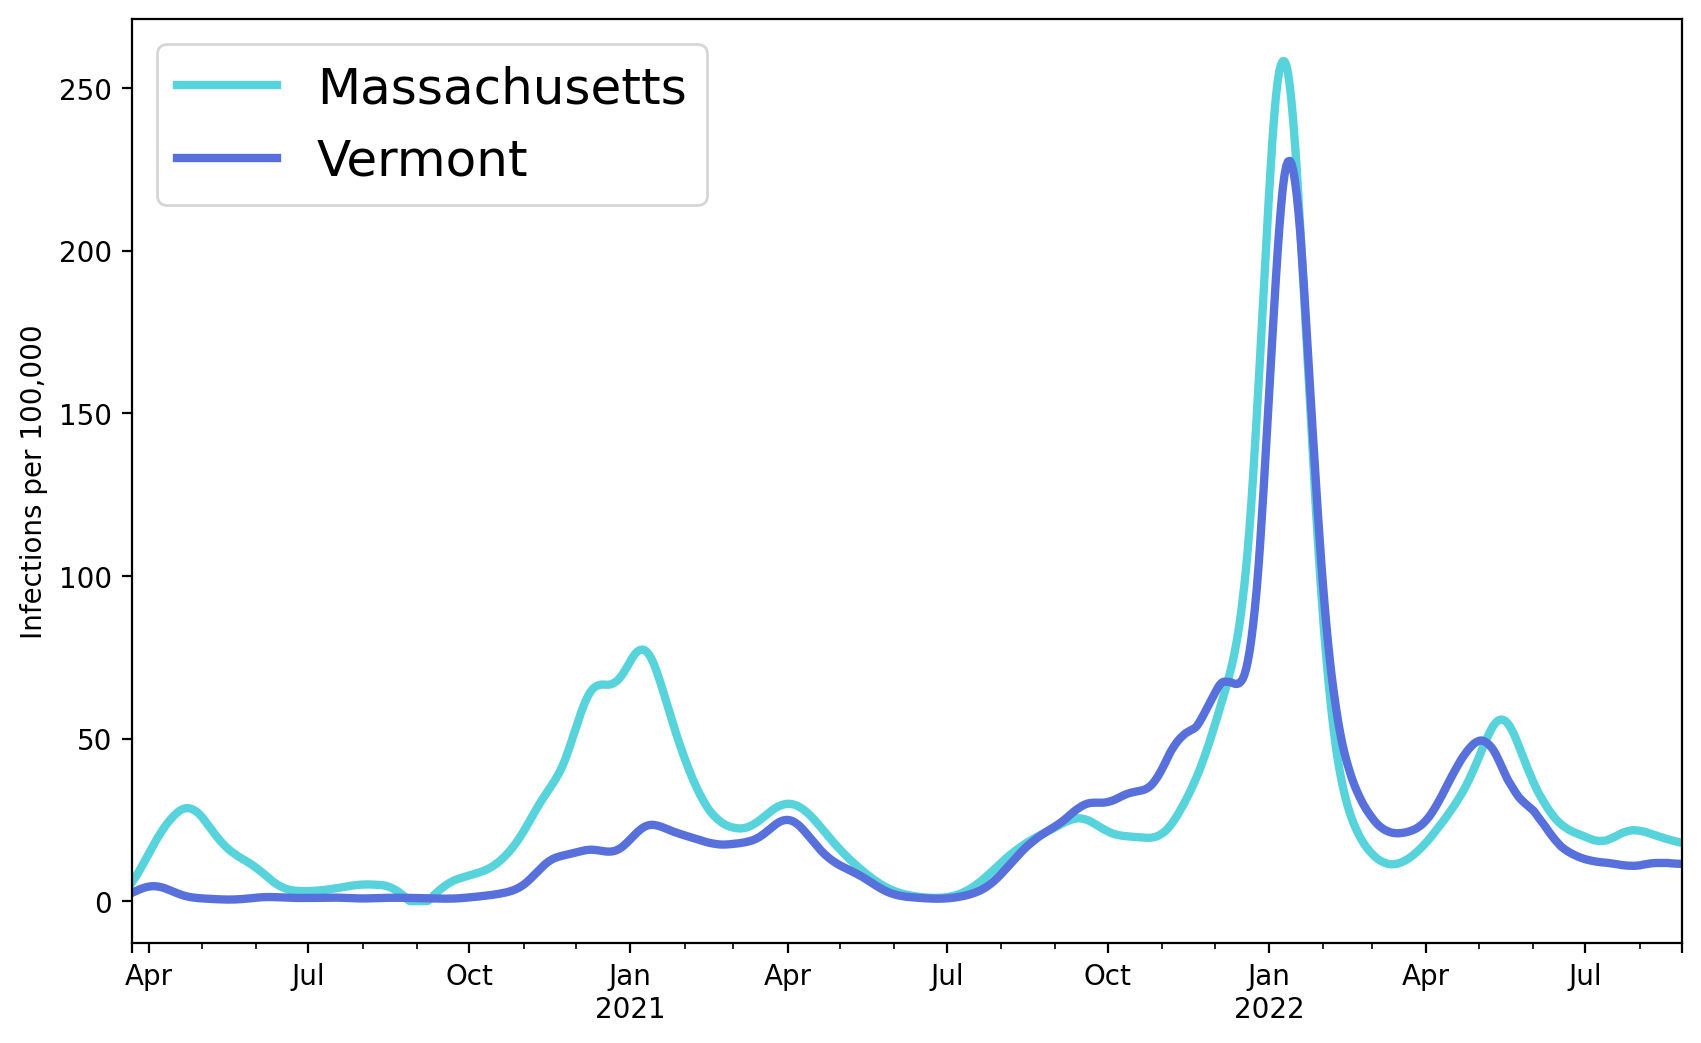

In [5]:
custom_palette = sns.color_palette("hls",8)[4:]
fix,ax = plt.subplots(dpi=200, figsize = (10,6))
plt.rcParams.update({'font.size':18})
sns.color_palette("hls", 8)
locations = ['US_MA', 'US_VT']
data.loc[:,locations].plot(ax=ax, color = custom_palette, linewidth = 3)
#sns.lineplot(data, x = data.index, y = locations[0], palette = 'hls')
#sns.lineplot(data, x = data.index, y = locations[1], palette = 'hls')
ax.set_ylabel('Infections per 100,000')
ax.set_xlabel('')
plt.legend(['Massachusetts', 'Vermont'])

# Segmentation

### Unimodal

In [6]:
# data vector to fit the model with
location = 'US_MA'
data_vec = data.loc[:,location].to_numpy().flatten().astype(np.float64)

In [10]:
# Find an appropriate segmentation penalty
penalties = np.linspace(0,0.1,21)
error_array = np.zeros(len(penalties))
for i,p in enumerate(penalties):
    unifit = Unimodal(penalty = p)
    unifit.fit(data_vec)
    error_array[i] = np.sum(unifit.errors)

In [11]:
np.linspace(0,0.1,21)

array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 , 0.055, 0.06 , 0.065, 0.07 , 0.075, 0.08 , 0.085,
       0.09 , 0.095, 0.1  ])

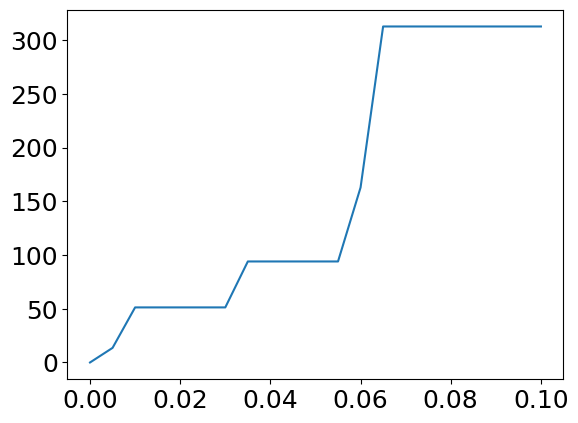

In [12]:
plt.plot(penalties, error_array)

In [8]:
unifit = Unimodal(penalty = 0.01, normalize = True)
unifit.fit(data_vec)
inflections = unifit.inflections
directions = unifit.directions
fit_vec = unifit.est
wave_inflections = unifit.waves

Text(0.5, 0, 'date')

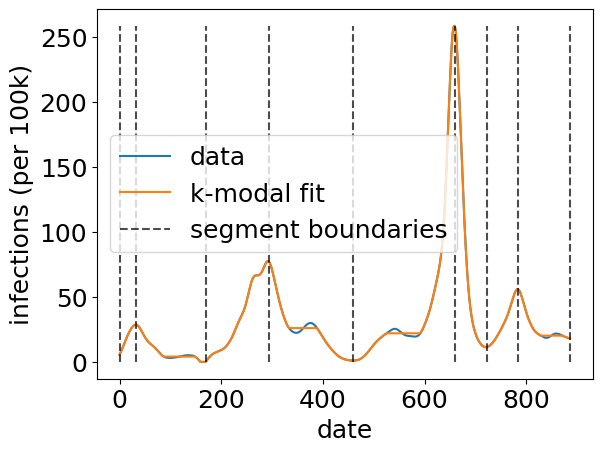

In [9]:
# and visualize the results!
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(inflections)):
    if i == 0:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

Text(0.5, 0, 'date')

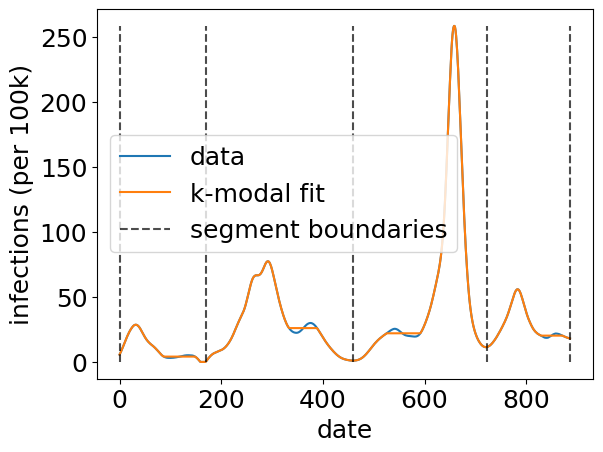

In [10]:
# Now showing the final result,
# which are the 'waves' instead of each isotonic piece.
fig,ax = plt.subplots(dpi = 100)
ax.plot(data_vec, label = 'data')
ax.plot(fit_vec, label = 'k-modal fit')

for i in range(len(wave_inflections)):
    if i == 0:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7, label = 'segment boundaries')
    else:
        ax.vlines(x = wave_inflections[i], ymin = np.min(data_vec), ymax = np.max(data_vec), 
                  color = 'black', linestyle = '--', alpha = 0.7)
plt.legend()
ax.set_ylabel('infections (per 100k)')
ax.set_xlabel('date')

# Dynamic Time Warp

Now that we have segments we'd like to be able to compare them. The problem is that these segments are varying in size and are usually offset in time. To avoid these issues we use dynamic time warping 

In [13]:
# first lets choose two segments to compare
#x = data.loc[:,'US_MA'][173:479].to_numpy()
#y = data.loc[:,'US_RI'][150:425].to_numpy()
x = data.loc[:,'US_MA'].to_numpy()
y = data.loc[:,'US_RI'].to_numpy()
x_masked = wave_mask(x, 173, 479)
y_masked = wave_mask(y, 173, 479)

# normalize them by the max of the larger 
norm = max(x_masked.max(), y_masked.max())

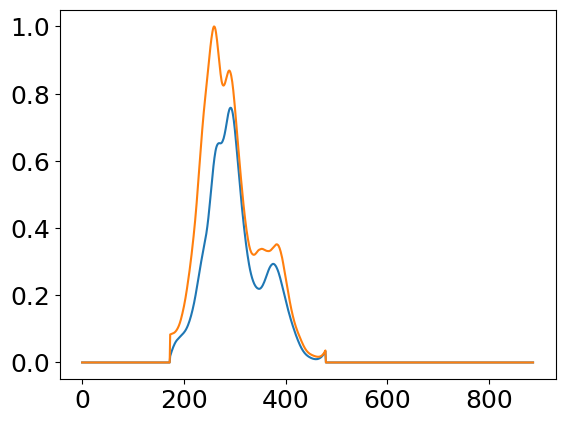

In [14]:
plt.plot(x_masked / norm)
plt.plot(y_masked / norm)

In [15]:
import time
DTW = DynamicTimeWarp(
    mult_penalty = [1.0,1.0,1.0],
    add_penalty = [0.05,0.05,0.0],
    normalize = True
)
start = time.time()
dist = DTW.fit(x_masked, y_masked)
end = time.time()
print(end - start)

3.686190128326416


In [16]:
dist

18.756994527035243

Text(0.5, 1.0, 'Alignment')

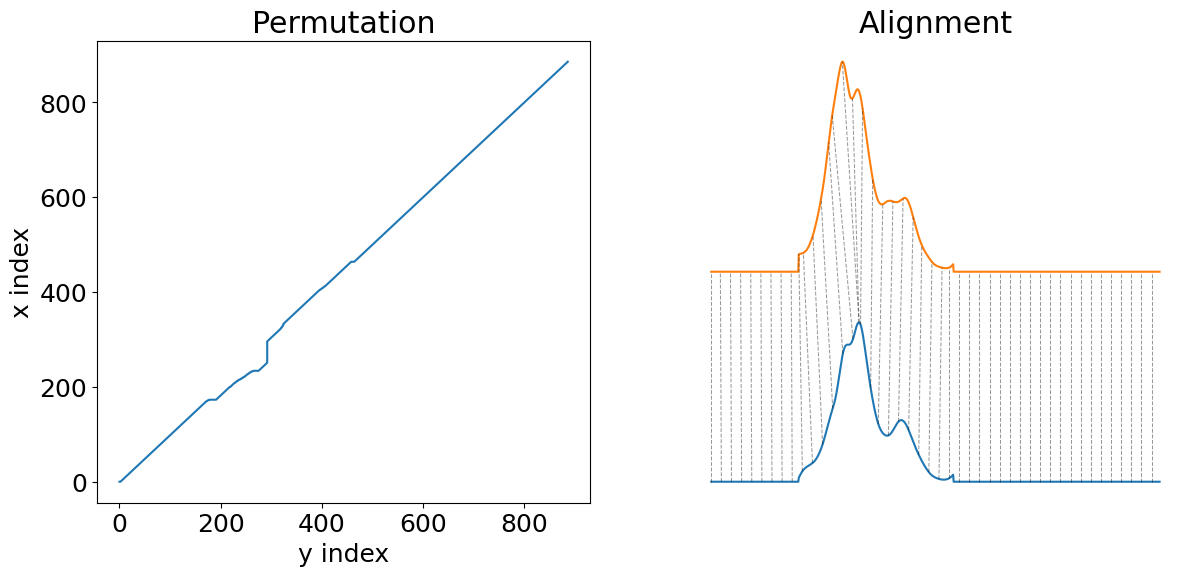

In [18]:
# and then plot the results
fig,ax = plt.subplots(1,2, figsize = (14,6), dpi = 100)
DTW.plot_permutation(axis = ax[0])
DTW.plot_alignment(x_masked / norm, y_masked / norm, offset = 1, skips = 20, axis = ax[1])
ax[0].set_ylabel('x index')
ax[0].set_xlabel('y index')
ax[1].axis('off')
ax[0].set_title('Permutation')
ax[1].set_title('Alignment')

### Wave Pool

In [27]:
wave_mod = Unimodal(penalty = 0.01, normalize = True)
dist_mod = DynamicTimeWarp(
    mult_penalty = [1.0,1.0,1.0],
    add_penalty = [0.05,0.05,0.0],
    normalize = True
)
wave_pool = WavePool(
    wave_module = wave_mod,
    distance_module = dist_mod,
    fit_waves_ = True,
    fit_distances_ = True,
    mask = True,
    cpu_count = 2
)

dataset = data.to_numpy()
dataset = dataset[:,:5]
wave_pool.fit(dataset)

In [31]:
wave_pool.pool.shape

(23, 3)

In [30]:
pd.DataFrame(wave_pool.distances)

,0,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
0,0.000000,69.374554,81.762047,55.101015,136.279547,59.872122,76.862208,53.544193,137.418884,16.485869,...,25.400136,60.455858,70.709683,50.655117,150.056914,46.333078,66.302447,82.569542,54.280250,154.885071
1,69.374554,0.000000,36.028172,64.013353,158.620233,28.612855,42.546109,60.987722,152.684832,52.614618,...,81.374039,19.957851,66.330360,64.051019,176.778273,32.485360,57.562170,69.409331,65.873667,179.228070
2,81.762047,36.028172,0.000000,34.438813,114.108935,50.765925,12.741019,33.945397,108.821878,69.924241,...,90.300891,37.268941,32.353136,34.802346,130.283510,55.133352,49.991678,31.843232,32.757900,104.592902
3,55.101015,64.013353,34.438813,0.000000,58.471679,75.847511,39.592068,6.049856,56.332936,55.308781,...,51.703145,55.711790,46.248338,4.263608,61.574196,74.045960,51.209513,41.154598,4.411367,53.642923
4,136.279547,158.620233,114.108935,58.471679,0.000000,169.112107,131.019938,56.424516,7.705200,137.025201,...,120.573753,110.290493,143.539142,53.461601,11.903479,140.286550,118.292063,165.072958,57.840850,25.258683
5,59.872122,28.612855,50.765925,75.847511,169.112107,0.000000,51.072557,71.359664,164.039036,45.256420,...,76.669144,28.942166,85.725300,74.044120,184.632044,25.184368,80.897843,74.856300,76.517321,188.922834
6,76.862208,42.546109,12.741019,39.592068,131.019938,51.072557,0.000000,38.052775,125.049541,65.999954,...,91.920488,42.030268,37.240209,39.154028,149.285041,48.469037,57.138051,32.440768,37.353052,119.435147
7,53.544193,60.987722,33.945397,6.049856,56.424516,71.359664,38.052775,0.000000,54.692234,53.721735,...,50.640623,55.353567,43.455489,3.474771,57.906886,70.869585,50.218801,37.710714,8.328303,49.829184
8,137.418884,152.684832,108.821878,56.332936,7.705200,164.039036,125.049541,54.692234,0.000000,127.669718,...,120.412480,105.845802,145.279653,51.773727,11.074890,134.842688,117.941841,156.738125,55.699436,21.931719
9,16.485869,52.614618,69.924241,55.308781,137.025201,45.256420,65.999954,53.721735,127.669718,0.000000,...,24.020846,50.113293,66.939226,50.828107,150.930576,39.686195,56.676104,73.216739,54.499724,155.745502


In [32]:
wave_pool.save_pool('../experiments/data/test_pool.npz')
wave_pool.save_distances('../experiments/data/test_distances.npz')

In [33]:
wave_pool.load_pool('../experiments/data/test_pool.npz')
wave_pool.load_distances('../experiments/data/test_distances.npz')

AttributeError: 'NpzFile' object has no attribute 'shape'

In [39]:
data_load = np.load('../experiments/data/test_distances.npz')

In [40]:
data_load['arr_0']

array([[  0.        ,  69.37455376,  81.76204674,  55.10101495,
        136.2795469 ,  59.87212232,  76.86220758,  53.54419319,
        137.41888392,  16.48586949,  59.84917331,  79.33876449,
        168.93236888,  25.40013584,  60.45585796,  70.70968266,
         50.65511655, 150.05691419,  46.33307802,  66.30244726,
         82.56954152,  54.28025043, 154.88507059],
       [ 69.37455376,   0.        ,  36.02817216,  64.01335346,
        158.62023259,  28.61285481,  42.5461087 ,  60.98772243,
        152.68483227,  52.61461803,  25.90287144,  63.95267514,
        153.05614778,  81.37403934,  19.95785086,  66.33036021,
         64.05101862, 176.7782726 ,  32.48535976,  57.56216969,
         69.40933085,  65.87366659, 179.22806999],
       [ 81.76204674,  36.02817216,   0.        ,  34.43881251,
        114.10893457,  50.7659254 ,  12.74101879,  33.94539718,
        108.8218782 ,  69.92424098,  38.8431563 ,  38.09991826,
        109.15263365,  90.30089056,  37.26894084,  32.35313638,
  